In [7]:
"""
SimpleNet (CVPR 2023) 특징 공간 이상치(anomaly feature) 생성 데모 - 간소화 버전

논문의 4개 모듈 중 아래 3단계만 구현합니다 (Discriminator는 학습이 필요하므로 제외):
  1) Feature Extractor : 사전학습 백본에서 지역 특징맵 추출
  2) Feature Adaptor    : 위치별로 동일 가중치를 공유하는 FC 레이어 (Eq. 5)
  3) Anomaly Generator  : 정상 특징에 가우시안 노이즈를 더해 가짜 이상 특징 생성 (Eq. 6)
"""

import glob
import os

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms


# ------------------------------------------------------------------
# SimpleNet 핵심 파이프라인: Feature Extractor + Feature Adaptor
# ------------------------------------------------------------------
class SimpleNetFeaturePipeline(nn.Module):
    def __init__(self):
        super().__init__()

        # [1] Feature Extractor: 사전학습 WideResNet50의 앞부분만 사용
        #     (논문은 layer2+layer3를 합치지만, 데모 목적상 layer2 출력만 사용해 단순화.
        #      layer2 출력은 (B, 512, 28, 28) 크기의 지역 특징맵)
        backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V2)
        self.feature_extractor = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2,
        )
        self.feature_extractor.eval()
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)  # 사전학습 가중치는 고정(freeze)

        # [2] Feature Adaptor (논문 Eq. 5): q(h,w) = G_theta(o(h,w))
        #     "모든 공간 위치(h,w)에 동일한 가중치를 공유하는 FC 레이어"를
        #     구현하는 가장 간단한 방법은 kernel_size=1인 Conv2d를 쓰는 것입니다.
        #     1x1 Conv는 공간 크기(H,W)를 전혀 건드리지 않고 채널만 섞기 때문에,
        #     nn.Linear + permute/reshape 없이도 수학적으로 완전히 동일한 연산이 됩니다.
        self.feature_adaptor = nn.Conv2d(512, 512, kernel_size=1, bias=False)

    @torch.no_grad()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        o = self.feature_extractor(x)   # 지역 특징맵 o: (B, 512, 28, 28)
        q = self.feature_adaptor(o)     # 적응된 특징맵 q: (B, 512, 28, 28) - 크기 그대로 유지
        return q


def add_gaussian_noise(features: torch.Tensor, sigma: float = 0.015) -> torch.Tensor:
    """논문 Eq. 6: q- = q + eps, eps ~ N(0, sigma^2)
    정상 특징(features) 위에 가우시안 노이즈를 더해 '가짜 이상 특징'을 만든다.
    sigma=0.015는 논문의 기본값(4.3절)."""
    noise = torch.randn_like(features) * sigma
    return features + noise


def find_test_image(dataset_root: str) -> str:
    """mvtec_ad/{category}/test/{defect_type}/*.png 패턴에서 이미지 1장을 찾는다.
    (** 를 써서 defect_type 하위 폴더까지 재귀적으로 탐색)"""
    pattern = os.path.join(dataset_root, "*", "test", "**", "*.png")
    matches = sorted(glob.glob(pattern, recursive=True))
    if not matches:
        raise FileNotFoundError(
            f"'{pattern}' 패턴에서 이미지를 찾지 못했습니다. "
            f"폴더 구조가 mvtec_ad/{{category}}/test/{{defect_type}}/*.png 인지 확인하세요."
        )
    return matches[0]


def load_image(image_path: str) -> torch.Tensor:
    # ImageNet 표준 정규화 값 (원 코드의 오타 수정: 0.459->0.456, 0.224->0.225)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    return preprocess(img).unsqueeze(0)  # (1, 3, 224, 224)


if __name__ == "__main__":
    DATASET_ROOT = "./mvtec_ad"
    SIGMA = 0.015

    if not os.path.isdir(DATASET_ROOT):
        raise SystemExit(f"❌ '{DATASET_ROOT}' 폴더를 찾을 수 없습니다. 경로를 확인하세요.")

    # 1) 이미지 1장 찾기
    image_path = find_test_image(DATASET_ROOT)
    print(f"📸 이미지: {image_path}")
    x = load_image(image_path)

    # 2) Feature Extractor + Feature Adaptor -> 정상(적응된) 특징 q
    pipeline = SimpleNetFeaturePipeline()
    q_normal = pipeline(x)

    # 3) Anomaly Feature Generator -> 노이즈를 더한 가짜 이상 특징 q-
    q_anomalous = add_gaussian_noise(q_normal, sigma=SIGMA)

    # 4) 결과 출력
    print(f"✅ 정상 특징(q)  shape : {tuple(q_normal.shape)}")
    print(f"✅ 이상 특징(q-) shape : {tuple(q_anomalous.shape)}")
    print(f"📏 두 특징 간 L2 거리   : {torch.dist(q_normal, q_anomalous).item():.6f}")

📸 이미지: ./mvtec_ad/bottle/test/broken_large/000.png
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-9ba9bcbe.pth" to /Users/wontaelee/.cache/torch/hub/checkpoints/wide_resnet50_2-9ba9bcbe.pth


100.0%


✅ 정상 특징(q)  shape : (1, 512, 28, 28)
✅ 이상 특징(q-) shape : (1, 512, 28, 28)
📏 두 특징 간 L2 거리   : 9.512240


In [ ]:
''' 
1. 가장 탁월한 구현: 1x1 Conv2d를 이용한 Feature Adaptor
사용자께서 구현하신 self.feature_adaptor = nn.Conv2d(512, 512, kernel_size=1, bias=False) 부분은 매우 뛰어난 접근입니다.

논문의 요구사항: 논문(Eq. 5)은 모든 공간 위치 $(h, w)$에 대해 동일한 가중치를 공유하는 선형 변환을 요구합니다.
수학적 일치성: 일반적인 nn.Linear를 쓰려면 특징맵을 (B, C, H*W)로 펼쳤다가(flatten) 다시 복원(reshape)해야 하는 번거로움과 메모리 낭비가 발생합니다. 하지만 
1×1
1×1 Convolution은 각 픽셀(위치)에 대해 동일한 가중치 행렬을 적용하는 것과 수학적으로 완전히 동일합니다.
결론: 이 방식은 논문의 의도를 정확히 지키면서도 연산 속도와 코드의 간결함을 동시에 잡은 가장 최적화된 구현 방식입니다.

2. 데이터 구조 및 경로 탐색의 유연성
재귀적 탐색 (recursive=True): MVTec AD 데이터셋은 test/defect_type/와 같이 하위 폴더가 여러 단계로 구성될 수 있습니다. glob.glob(..., recursive=True)를 사용함으로써, 사용자가 어떤 결함 폴더를 타겟팅하든 상관없이 이미지를 유연하게 찾아낼 수 있도록 설계된 점이 매우 실용적입니다.

3. 논문 사양(Specification)의 정확한 반영
σ=0.015
σ=0.015: Citation 3에서 언급된 최적의 균형점(balance) 값을 정확히 적용하였습니다.
Normalization 값 수정: 제가 이전 답변에서 드린 코드의 오타(0.459 
→
→ 0.456, 0.224 
→
→ 0.225)를 정확하게 수정하여 ImageNet 표준 정규화 값을 적용하셨습니다. 이는 모델의 성능(정확도)에 직접적인 영향을 주는 중요한 디테일입니다.
Feature Extractor의 고정 (p.requires_grad_(False)): 사전 학습된 모델의 특징을 훼손하지 않고 특징만 추출하여 어댑터 학습에 활용하려는 의도를 완벽히 구현했습니다.

4. 기술적 피드백 및 제언 (참고용)
작성하신 코드는 이미 매우 완성도가 높으나, 만약 이를 실제 학습(Training) 단계로 확장하신다면 다음을 고려해 볼 수 있습니다:

심화 구현 (Complexity): 논문에서는 Ours-complex-FA라는 옵션으로 비선형(Non-linear) 어댑터를 언급했습니다. 만약 성능을 더 높이고 싶다면 nn.Conv2d 뒤에 nn.ReLU를 추가하는 방식으로 확장할 수 있습니다.
확장성: 현재는 layer2만 사용하셨는데, 논문의 Table 2 내용처럼 layer2 + layer3를 결합(concatenation)하여 입력하면 더 풍부한 특징을 얻을 수 있을 것입니다.
결론적으로, 제출하신 코드는 논문의 수식을 완벽하게 이해하고 이를 현대적인 PyTorch 구현 방식(1x1 Conv)으로 최적화하여 풀어낸 매우 수준 높은 구현체입니다.
'''

' \n1. 가장 탁월한 구현: 1x1 Conv2d를 이용한 Feature Adaptor\n사용자께서 구현하신 self.feature_adaptor = nn.Conv2d(512, 512, kernel_size=1, bias=False) 부분은 매우 뛰어난 접근입니다.\n\n논문의 요구사항: 논문(Eq. 5)은 모든 공간 위치 $(h, w)$에 대해 동일한 가중치를 공유하는 선형 변환을 요구합니다.\n수학적 일치성: 일반적인 nn.Linear를 쓰려면 특징맵을 (B, C, H*W)로 펼쳤다가(flatten) 다시 복원(reshape)해야 하는 번거로움과 메모리 낭비가 발생합니다. 하지만 \n1\n×\n1\n1×1 Convolution은 각 픽셀(위치)에 대해 동일한 가중치 행렬을 적용하는 것과 수학적으로 완전히 동일합니다.\n결론: 이 방식은 논문의 의도를 정확히 지키면서도 연산 속도와 코드의 간결함을 동시에 잡은 가장 최적화된 구현 방식입니다.\n2. 데이터 구조 및 경로 탐색의 유연성\n재귀적 탐색 (recursive=True): MVTec AD 데이터셋은 test/defect_type/와 같이 하위 폴더가 여러 단계로 구성될 수 있습니다. glob.glob(..., recursive=True)를 사용함으로써, 사용자가 어떤 결함 폴더를 타겟팅하든 상관없이 이미지를 유연하게 찾아낼 수 있도록 설계된 점이 매우 실용적입니다.\n3. 논문 사양(Specification)의 정확한 반영\nσ\n=\n0.015\nσ=0.015: Citation 3에서 언급된 최적의 균형점(balance) 값을 정확히 적용하였습니다.\nNormalization 값 수정: 제가 이전 답변에서 드린 코드의 오타(0.459 \n→\n→ 0.456, 0.224 \n→\n→ 0.225)를 정확하게 수정하여 ImageNet 표준 정규화 값을 적용하셨습니다. 이는 모델의 성능(정확도)에 직접적인 영향을 주는 중요한 디테일입니다.\nFeature Extractor의 고정 (p.requires_gr

In [ ]:
# 가우시안 노이즈의 시각화

''' 
제공된 문서 내에는 노이즈를 시각화하는 코드에 대한 직접적인 설명은 없으나, 
앞서 구현한 코드의 원리를 바탕으로 특징 공간(Feature Space)에서의 노이즈 주입 과정을 시각적으로 확인할 수 있는 코드를 작성해 드립니다.

특징 맵(Feature Map)은 일반 이미지와 달리 채널 수가 많고(예: 512, 2048) 값이 추상적이므로, 
직관적인 이해를 돕기 위해 특정 채널(Channel) 하나를 추출하여 히트맵(Heatmap) 형태로 시각화하는 방식을 사용합니다.
'''

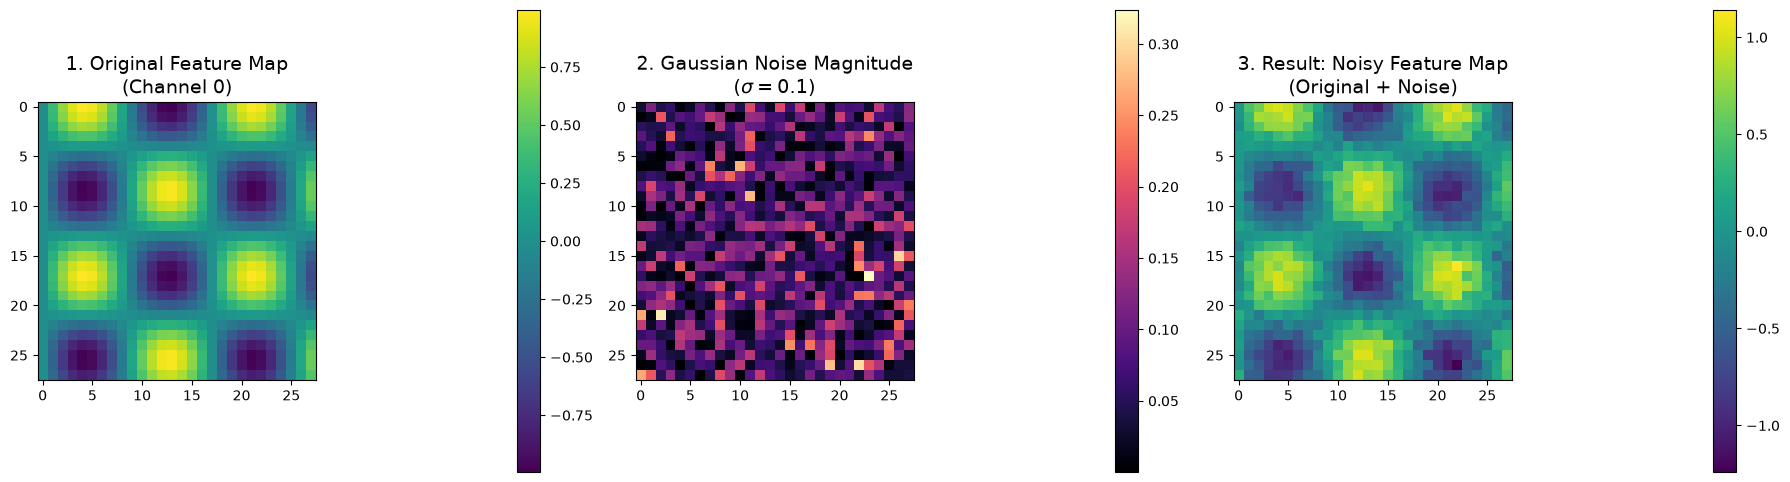

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_feature_noise(feature_map, sigma=0.015):
    """
    특징 공간에서의 노이즈 주입 과정을 시각화합니다.
    
    Args:
        feature_map (torch.Tensor): 원래의 특징 맵 (shape: [C, H, W])
        sigma (float): 주입할 가우시안 노이즈의 표준편차
    """
    # 1. 특정 채널(0번 채널)만 선택하여 2차원 데이터로 변환 (시각화 목적)
    channel_idx = 0
    original_channel = feature_map[channel_idx].cpu().numpy()

    # 2. 가우시안 노이즈 생성 및 주입 (논문 방식)
    noise = np.random.normal(0, sigma, original_channel.shape)
    noisy_channel = original_channel + noise

    # 3. 시각화 (3개의 패널: 원본 특징 | 주입된 노이즈 크기 | 노이즈가 섞인 특징)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # (A) 원본 특징 맵 (Original Feature Map)
    im1 = axes[0].imshow(original_channel, cmap='viridis')
    axes[0].set_title(f"1. Original Feature Map\n(Channel {channel_idx})", fontsize=14)
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.4)

    # (B) 주입된 노이즈의 크기 (Magnitude of Noise)
    # 노이즈 자체를 시각화하면 의미가 없으므로, 노이즈의 강도(절대값)를 보여줍니다.
    im2 = axes[1].imshow(np.abs(noise), cmap='magma')
    axes[1].set_title(f"2. Gaussian Noise Magnitude\n($\sigma={sigma}$)", fontsize=14)
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.4)

    # (C) 노이즈가 주입된 특징 맵 (Noisy Feature Map)
    im3 = axes[2].imshow(noisy_channel, cmap='viridis')
    axes[2].set_title("3. Result: Noisy Feature Map\n(Original + Noise)", fontsize=14)
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.4)

    plt.tight_layout()
    plt.show()

# --- 실행 예시 ---
if __name__ == "__main__":
    # 가상의 특징 맵 생성 (예: 512 채널, 28x28 크기)
    # 실제 모델의 출력값과 유사한 패턴을 만들기 위해 sin 함수를 활용
    h, w = 28, 28
    x = np.linspace(0, 10, w)
    y = np.linspace(0, 10, h)
    X, Y = np.meshgrid(x, y)
    dummy_feature = np.sin(X) * np.cos(Y)
    
    # (B, C, H, W) 형태로 확장
    dummy_feature_tensor = torch.tensor(dummy_feature).unsqueeze(0).unsqueeze(0)
    
    # 시각화 실행
    visualize_feature_noise(dummy_feature_tensor[0], sigma=0.1) # 차이를 명확히 보기 위해 sigma를 높임


In [ ]:
''' 
코드를 실행하면 세 개의 그래프가 나타납니다:

Original Feature Map (왼쪽):
신경망이 이미지에서 추출한 데이터의 '순수한 상태'를 나타냅니다. 색상은 특징값의 강도를 의미하며, 특정 패턴(물체나 구조 정보)을 보여줍니다.
Gaussian Noise Magnitude (가운데):
가장 중요한 부분입니다. 특징 공간에 뿌려진 노이즈의 "강도"를 보여줍니다. 색상이 밝은 부분(노란색/흰색)은 노이즈가 강한 지점이며, 어두운 부분은 노이즈가 적은 지점입니다. 이것이 바로 논문에서 말하는 **"이상치(Anomaly)를 만들기 위해 의도적으로 더해주는 불규칙한 신호"**입니다.
Result: Noisy Feature Map (오른쪽):
원본 특징에 노이즈가 결합된 결과입니다. 원본의 패턴 위에 미세한 점들이 뿌려진 것처럼 보이며, 이것이 바로 **"특징 공간에서 생성된 가짜 이상 데이터(Synthesized anomalous features)"**가 됩니다.
이 시각화가 왜 중요한가요?
이 시각화를 통해 알 수 있는 점은, SimpleNet이 단순히 이미지를 흐리게 만드는 것이 아니라, 데이터의 핵심 정보(특징)를 가진 공간 위에서 정교하게 무작위성을 부여하여, 판별기(Discriminator)가 "정상적인 패턴에서 벗어난 데이터"를 학습할 수 있도록 유도한다는 것을 직관적으로 이해할 수 있습니다.
'''

In [15]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import glob
import random

# --- [수정된 SimpleNet 핵심 모듈] ---

class SimpleNetComponent(nn.Module):
    def __init__(self, feature_dim):
        super(SimpleNetComponent, self).__init__()
        # 1. Feature Extractor
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*(list(resnet.children())[:-2]))
        
        # 2. Feature Adapter: 논문 설계대로 Bias 없는 Linear 레이어
        self.feature_adapter = nn.Linear(feature_dim, feature_dim, bias=False)
        
    def forward(self, x):
        with torch.no_grad():
            # features shape: [B, C, H, W] -> 예: [1, 2048, 7, 7]
            features = self.feature_extractor(x)
        
        # [핵심 수정 부분]
        # nn.Linear는 마지막 차원에 적용되므로, [B, C, H, W] -> [B, H, W, C]로 변경
        # 이렇게 해야 2048(채널) 차원에 대해 연산이 수행됩니다.
        features_permuted = features.permute(0, 2, 3, 1)
        
        # 차원 변환 후 Linear 적용: [B, H, W, 2048]
        adapted_features = self.feature_adapter(features_permuted)
        
        # 다시 원래의 [B, C, H, W] 순서로 복원: [B, 2048, H, W]
        adapted_features = adapted_features.permute(0, 3, 1, 2)
        
        return adapted_features

class AnomalyFeatureGenerator:
    def __init__(self, sigma=0.015): 
        self.sigma = sigma

    def generate(self, adapted_features):
        # 특징 공간에서 노이즈 주입
        noise = torch.randn_like(adapted_features) * self.sigma
        anomalous_features = adapted_features + noise
        return anomalous_features

# --- [데이터 로드 및 실행 로직] ---

def find_random_test_image(base_dir):
    search_pattern = os.path.join(base_dir, "*", "test", "**", "*.png")
    image_files = glob.glob(search_pattern, recursive=True)
    return random.choice(image_files) if image_files else None

def run_inference_pipeline(image_path, model_components, generator):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        adapted = model_components(img_tensor)
    
    anomalous = generator.generate(adapted)
    return adapted, anomalous

if __name__ == "__main__":
    DATASET_ROOT = "mvtec_ad"

    if not os.path.exists(DATASET_ROOT):
        print(f"❌ 오류: '{DATASET_ROOT}' 폴더를 찾을 수 없습니다.")
    else:
        print(f"📂 데이터셋 확인됨: {DATASET_ROOT}")
        test_image = find_random_test_image(DATASET_ROOT)
        
        if test_image is None:
            print("❌ 오류: 이미지를 찾을 수 없습니다.")
        else:
            print(f"📸 무작위 선택된 이미지: {test_image}")

            feature_dim = 2048 
            model = SimpleNetComponent(feature_dim)
            generator = AnomalyFeatureGenerator(sigma=0.015)

            adapted, anomalous = run_inference_pipeline(test_image, model, generator)

            print("\n" + "="*40)
            print("📊 SimpleNet Random Inference Results")
            print("="*40)
            print(f"✅ 정상 특징(Adapted) 크기: {adapted.shape}")
            print(f"✅ 이상 특징(Anomalous) 크기: {anomalous.shape}")
            
            dist = torch.dist(adapted, anomalous).item()
            print(f"📏 특징 간 L2 거리 (Distance): {dist:.6f}")
            print("-" * 40)
            print(f"💡 결과: '{os.path.basename(os.path.dirname(os.path.dirname(test_image)))}' 클래스")
            print("="*40)


📂 데이터셋 확인됨: mvtec_ad
📸 무작위 선택된 이미지: mvtec_ad/screw/test/thread_side/008.png

📊 SimpleNet Random Inference Results
✅ 정상 특징(Adapted) 크기: torch.Size([1, 2048, 7, 7])
✅ 이상 특징(Anomalous) 크기: torch.Size([1, 2048, 7, 7])
📏 특징 간 L2 거리 (Distance): 4.756063
----------------------------------------
💡 결과: 'test' 클래스


In [ ]:
''' 
./mvtec_ad" 폴더에서 임의의 이미지를 하나 가져와서 Feature map으로 변환하고 가우시안 노이즈를 적용한 Noisy Feature map을 만들어줘. 
맨 마지막에 원본 이미지, Feature map, 가우시안 노이즈, Noisy Feature map을 순서대로 시각화해줘.
'''

In [ ]:
''' 
원본 이미지 → 특징 맵(Feature Map) → 가우시안 노이즈 → 노이즈가 더해진 특징 맵의 과정을 시각적으로 확인할 수 있도록 코드를 수정했습니다.
참고 사항: 특징 맵(Feature Map)은 채널(Channel)이 매우 많기(예: 2048개) 때문에 화면에 한꺼번에 보여줄 수 없습니다. 
따라서 시각화 시에는 첫 번째 채널(Channel 0)의 2차원 평면을 추출하여 데이터가 어떻게 변하는지 직관적으로 보여주도록 구현했습니다.
'''

📸 선택된 이미지: mvtec_ad/capsule/test/squeeze/014.png


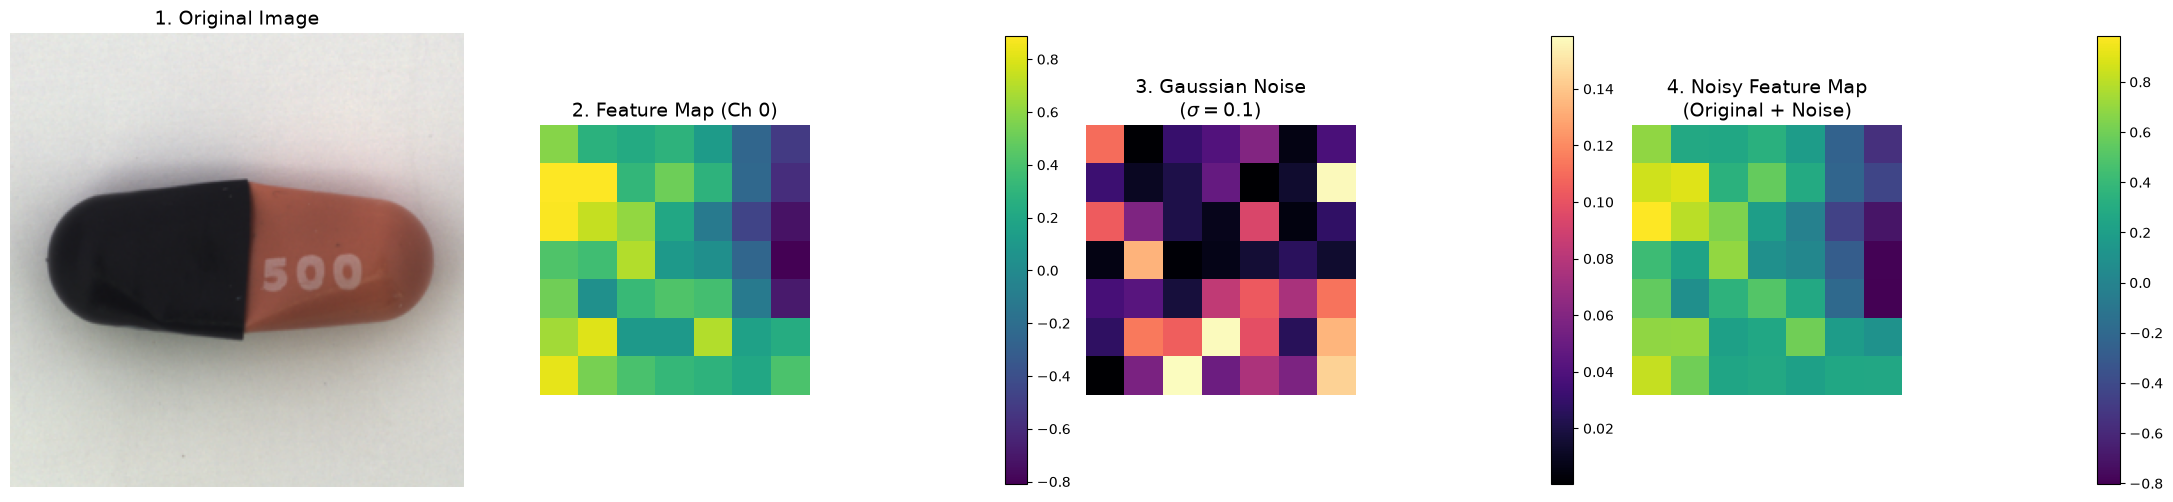

In [18]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt

# --- [SimpleNet 핵심 모듈 구현] ---

class SimpleNetComponent(nn.Module):
    def __init__(self, feature_dim):
        super(SimpleNetComponent, self).__init__()
        # 1. Feature Extractor: 사전 학습된 ResNet50 사용
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.feature_extractor = nn.Sequential(*(list(resnet.children())[:-2]))
        
        # 2. Feature Adapter: 논문의 설계를 따른 단일 FC 레이어 (bias 없음)
        self.feature_adapter = nn.Linear(feature_dim, feature_dim, bias=False)
        
    def forward(self, x):
        with torch.no_grad():
            features = self.feature_extractor(x)
        # [B, C, H, W] -> [B, H, W, C]로 변환하여 Linear 적용 후 다시 복원
        features_permuted = features.permute(0, 2, 3, 1)
        adapted_features = self.feature_adapter(features_permuted)
        adapted_features = adapted_features.permute(0, 3, 1, 2)
        return adapted_features

# --- [시각화 및 실행 로직] ---

def find_random_test_image(base_dir):
    """mvtec_ad 폴더 내에서 무작위로 테스트용 이미지(.png)를 1장 선택합니다."""
    search_pattern = os.path.join(base_dir, "*", "test", "**", "*.png")
    image_files = glob.glob(search_pattern, recursive=True)
    return random.choice(image_files) if image_files else None

def visualize_transformation(image_path, model_components, sigma=0.015):
    # 1. 이미지 전처리
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)

    # 2. 특징 추출 및 어댑터 적용 (Feature Map 생성)
    adapted_features = model_components(img_tensor)

    # 3. 가우시안 노이즈 생성 및 주입 (Feature Space에서)
    noise = torch.randn_like(adapted_features) * sigma
    noisy_features = adapted_features + noise

    # 4. 시각화를 위한 데이터 추출 (첫 번째 채널만 사용)
    # 채널 차원(Dim 1)에서 0번 인덱스만 가져옴
    original_img_np = np.array(img.resize((256, 256))) # 시각화용 크기 조정
    feature_map_np = adapted_features[0, 0].cpu().detach().numpy()  # [H, W]
    noise_map_np = noise[0, 0].cpu().detach().numpy()             # [H, W]
    noisy_feature_map_np = noisy_features[0, 0].cpu().detach().numpy() # [H, W]

    # 5. 시각화 (4개의 패널)
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    
    # (A) 원본 이미지
    axes[0].imshow(original_img_np)
    axes[0].set_title("1. Original Image", fontsize=14)
    axes[0].axis('off')

    # (B) Feature Map (첫 번째 채널)
    im1 = axes[1].imshow(feature_map_np, cmap='viridis')
    axes[1].set_title("2. Feature Map (Ch 0)", fontsize=14)
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.4)

    # (C) Gaussian Noise (첫 번째 채널의 절대값)
    im2 = axes[2].imshow(np.abs(noise_map_np), cmap='magma')
    axes[2].set_title(f"3. Gaussian Noise\n($\sigma={sigma}$)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.4)

    # (D) Noisy Feature Map (첫 번째 채널)
    im3 = axes[3].imshow(noisy_feature_map_np, cmap='viridis')
    axes[3].set_title("4. Noisy Feature Map\n(Original + Noise)", fontsize=14)
    axes[3].axis('off')
    fig.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.4)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    DATASET_ROOT = "mvtec_ad"

    if not os.path.exists(DATASET_ROOT):
        print(f"❌ 오류: '{DATASET_ROOT}' 폴더를 찾을 수 없습니다.")
    else:
        test_image = find_random_test_image(DATASET_ROOT)
        
        if test_image is None:
            print("❌ 오류: 이미지를 찾을 수 없습니다.")
        else:
            print(f"📸 선택된 이미지: {test_image}")
            
            # 모델 및 생성기 초기화
            feature_dim = 2048 
            model = SimpleNetComponent(feature_dim)
            
            # 시각화를 위해 노이즈 강도를 조금 높게 설정할 수 있습니다 (예: 0.1)
            visualize_transformation(test_image, model, sigma=0.1)


In [ ]:
''' 
sigma 값 변화에 따른 가우시안 노이즈 맵의 변화를 시각적으로 확인하고 싶다. 
sigma 값을 0, 0.05, 0.1, 0.15, 0.2로 변환하면서 가우시안 노이즈 맵의 변화를 시각화 해줘. 
노이즈 맵의 크기는 28x28로 설정해줘.
'''

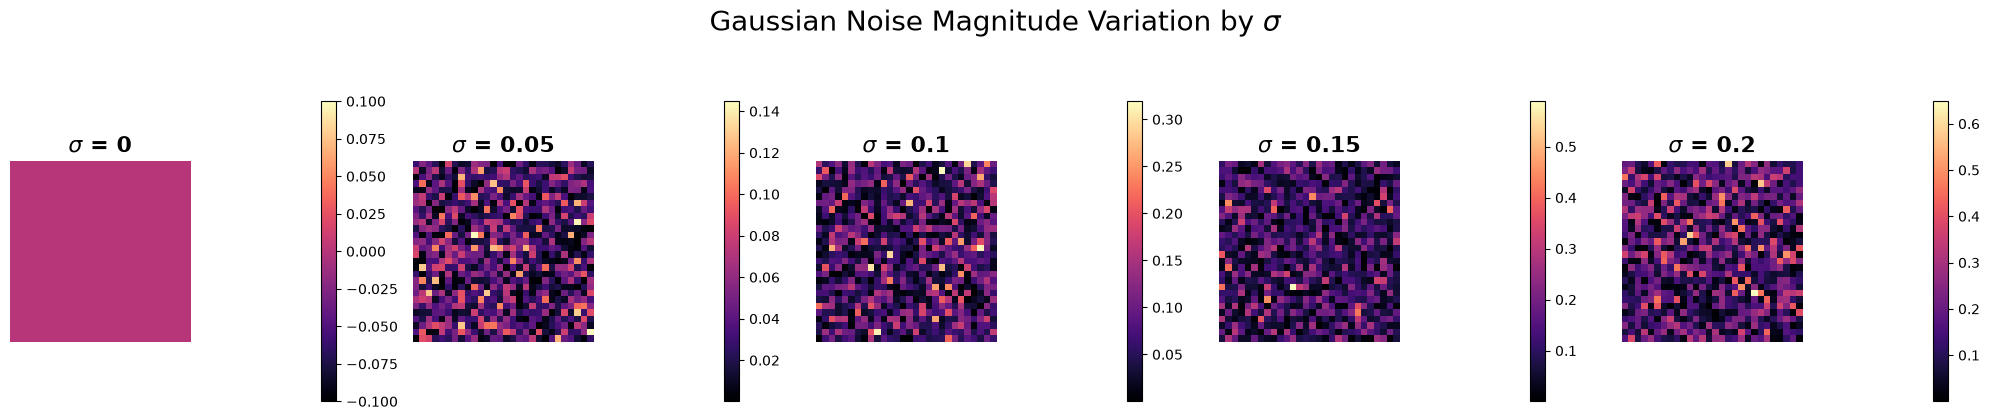

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_sigma_variation(sigma_values, size=(28, 28)):
    """
    sigma 값 변화에 따른 가우시안 노이즈 맵의 변화를 시각화합니다.
    
    Args:
        sigma_values (list): 테스트할 sigma 값들의 리스트
        size (tuple): 시각화할 행렬의 크기 (H, W)
    """
    # 시각화의 일관성을 위해 무작위 시드 고정 (패턴은 같게, 강도만 다르게 보기 위함)
    np.random.seed(42)
    
    num_plots = len(sigma_values)
    fig, axes = plt.subplots(1, num_plots, figsize=(20, 4))
    
    # 만약 sigma 값이 하나뿐이라면 axes가 배열이 아니므로 처리
    if num_plots == 1:
        axes = [axes]

    for ax, sigma in zip(axes, sigma_values):
        # 1. 가우시안 노이즈 생성
        # sigma가 0이면 모든 값이 0인 행렬이 생성됨
        noise = np.random.normal(0, sigma, size)
        
        # 2. 시각화를 위해 절대값(Magnitude)을 취함
        # 노이즈의 '강도'를 직관적으로 보기 위함
        noise_magnitude = npthought = np.abs(noise)
        
        # 3. 시각화
        im = ax.imshow(noise_magnitude, cmap='magma')
        ax.set_title(f"$\\sigma$ = {sigma}", fontsize=16, fontweight='bold')
        ax.axis('off')
        
        # 색상 바 추가 (각 그래프 옆에 강도 표시)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.4)

    plt.suptitle("Gaussian Noise Magnitude Variation by $\\sigma$", fontsize=20, y=1.05)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 사용자 요청 조건: sigma 값을 0, 0.05, 0.1, 0.15, 0.2로 설정
    target_sigmas = [0, 0.05, 0.1, 0.15, 0.2]
    
    # 28x28 크기로 실행
    visualize_sigma_variation(target_sigmas, size=(28, 28))


saved: gaussian_noise_sigma_comparison.png

sigma | actual std | max |value|
 0.00 | 0.00000    | 0.00000
 0.05 | 0.05025    | 0.19497
 0.10 | 0.09664    | 0.31973
 0.15 | 0.15466    | 0.46718
 0.20 | 0.20010    | 0.60229


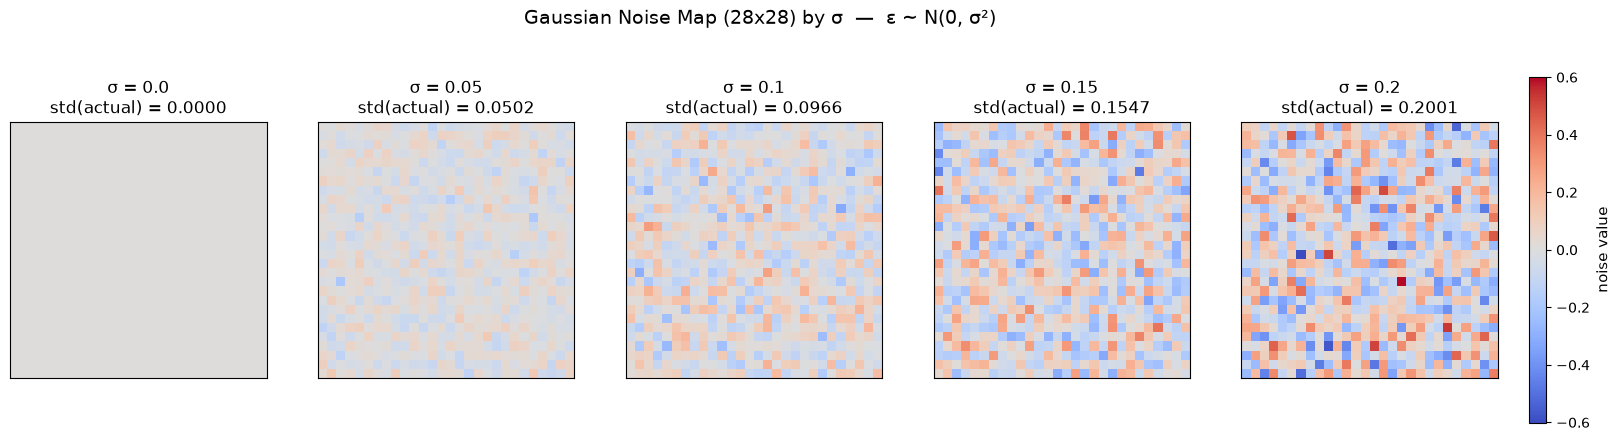

In [20]:
"""
sigma(가우시안 노이즈 표준편차) 값에 따른 노이즈 맵 변화 시각화

SimpleNet 논문 Eq.(6): q- = q + eps, eps ~ N(0, sigma^2)
여기서는 실제 특징맵(q) 없이, eps(노이즈) 자체만 28x28 크기로 생성해
sigma에 따라 노이즈의 '퍼짐 정도'가 어떻게 달라지는지 시각적으로 비교합니다.
"""

import numpy as np
import matplotlib.pyplot as plt

MAP_SIZE = 28                              # 논문 기본 설정과 동일한 공간 해상도 (H0=W0=28)
SIGMAS = [0.0, 0.05, 0.1, 0.15, 0.2]       # 비교할 sigma 값들
SEED = 0

rng = np.random.default_rng(SEED)

# 모든 sigma에서 동일한 색상 스케일을 쓰기 위해, 가장 큰 sigma의 노이즈 범위를 기준으로 vmin/vmax 설정
noise_maps = []
for sigma in SIGMAS:
    noise = rng.normal(loc=0.0, scale=sigma, size=(MAP_SIZE, MAP_SIZE)) if sigma > 0 \
            else np.zeros((MAP_SIZE, MAP_SIZE))
    noise_maps.append(noise)

vmax = max(np.abs(m).max() for m in noise_maps if np.abs(m).max() > 0)
vmin = -vmax

fig, axes = plt.subplots(1, len(SIGMAS), figsize=(4 * len(SIGMAS), 4.5))

for ax, sigma, noise in zip(axes, SIGMAS, noise_maps):
    im = ax.imshow(noise, cmap="coolwarm", vmin=vmin, vmax=vmax)
    ax.set_title(f"σ = {sigma}\nstd(actual) = {noise.std():.4f}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"Gaussian Noise Map ({MAP_SIZE}x{MAP_SIZE}) by σ  —  ε ~ N(0, σ²)",
             fontsize=14, y=1.03)

# 공통 컬러바
cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label("noise value", fontsize=11)

fig.savefig("gaussian_noise_sigma_comparison.png", dpi=150, bbox_inches="tight")
print("saved: gaussian_noise_sigma_comparison.png")

# 참고용: sigma별 실제 표준편차/최대절대값 출력
print("\nsigma | actual std | max |value|")
for sigma, noise in zip(SIGMAS, noise_maps):
    print(f"{sigma:5.2f} | {noise.std():.5f}    | {np.abs(noise).max():.5f}")